# Working with Text Data

Notebook ini membahas cara mengolah data teks agar dapat digunakan dalam machine learning. Fokus utama chapter ini adalah representasi teks, seperti **bag-of-words**, **CountVectorizer**, **stopwords**, **TF-IDF**, **n-grams**, serta penerapannya pada klasifikasi sentimen sederhana.

Notebook disusun dalam Bahasa Indonesia dengan contoh kode yang dapat langsung dijalankan tanpa perlu mengunduh dataset eksternal.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami karakteristik data teks dalam machine learning.
- Membedakan beberapa jenis data string.
- Mengubah teks menjadi representasi numerik.
- Menggunakan `CountVectorizer` untuk membuat bag-of-words.
- Memahami sparse matrix pada data teks.
- Menggunakan `min_df` dan stopwords untuk mengurangi fitur tidak informatif.
- Menggunakan `TfidfVectorizer` untuk memberi bobot kata berdasarkan kepentingannya.
- Memahami konsep n-grams.
- Membangun pipeline klasifikasi teks sederhana.
- Menginterpretasikan kata yang berpengaruh terhadap prediksi model.

## Persiapan Library

Library utama yang digunakan adalah `scikit-learn`, `pandas`, `numpy`, dan `matplotlib`. Dataset dibuat secara sederhana agar notebook tetap ringan dan dapat dijalankan langsung.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
pd.set_option("display.max_columns", 100)

## Ringkasan Chapter

Data teks berbeda dari data numerik biasa. Teks biasanya berbentuk string dengan panjang yang berbeda-beda, sehingga tidak bisa langsung dimasukkan ke algoritma machine learning. Agar dapat digunakan oleh model, teks perlu diubah menjadi representasi numerik.

Chapter ini menjelaskan bahwa salah satu cara paling sederhana dan sering digunakan adalah **bag-of-words**. Dalam pendekatan ini, teks diubah menjadi hitungan kemunculan kata. Struktur kalimat, urutan kata, dan konteks yang lebih luas sebagian besar diabaikan. Walaupun sederhana, metode ini sering cukup efektif untuk tugas klasifikasi teks.

Selain bag-of-words, chapter ini juga membahas peningkatan representasi teks melalui TF-IDF dan n-grams.

## Jenis Data String

Tidak semua data berbentuk string harus diperlakukan sebagai teks bebas. Sebelum melakukan pemrosesan, perlu dipahami jenis string yang sedang dihadapi.

| Jenis String | Contoh | Perlakuan Umum |
|---|---|---|
| Categorical data | warna: merah, biru, hijau | One-hot encoding |
| Free string yang bisa dipetakan ke kategori | “dark blue”, “navy”, “blue-ish” | Dibersihkan lalu dipetakan ke kategori |
| Structured string | tanggal, nomor telepon, alamat | Parsing khusus sesuai format |
| Text data | review, email, komentar | Text preprocessing dan vectorization |

Pada chapter ini, fokus utama adalah text data, yaitu teks bebas seperti review film, email, atau komentar pengguna.

## Contoh Dataset: Sentiment Analysis Sederhana

Pada buku, contoh utama menggunakan review film IMDb untuk klasifikasi sentimen positif dan negatif. Agar notebook ini ringan, kita menggunakan dataset kecil buatan yang tetap menunjukkan konsep serupa.

Target klasifikasi:
- `1` = sentimen positif
- `0` = sentimen negatif

In [2]:
texts = [
    "film ini sangat bagus dan ceritanya menyenangkan",
    "akting pemainnya luar biasa dan filmnya sangat menarik",
    "saya suka film ini karena alurnya bagus",
    "cerita film ini menyentuh dan endingnya memuaskan",
    "film yang hebat dengan visual yang indah",
    "pengalaman menonton yang sangat menyenangkan",
    "film ini buruk dan sangat membosankan",
    "ceritanya jelek dan aktingnya kaku",
    "saya tidak suka film ini karena alurnya membingungkan",
    "film ini terlalu panjang dan membosankan",
    "endingnya buruk dan tidak memuaskan",
    "film ini gagal membuat saya tertarik",
    "visualnya bagus tetapi ceritanya buruk",
    "aktingnya bagus namun alurnya membosankan",
    "film ini cukup menarik dan punya pesan bagus",
    "ceritanya buruk tetapi beberapa adegan cukup bagus"
]

labels = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

data = pd.DataFrame({
    "text": texts,
    "sentiment": labels
})

data

,text,sentiment
0,film ini sangat bagus dan ceritanya menyenangkan,1
1,akting pemainnya luar biasa dan filmnya sangat...,1
2,saya suka film ini karena alurnya bagus,1
3,cerita film ini menyentuh dan endingnya memuaskan,1
4,film yang hebat dengan visual yang indah,1
5,pengalaman menonton yang sangat menyenangkan,1
6,film ini buruk dan sangat membosankan,0
7,ceritanya jelek dan aktingnya kaku,0
8,saya tidak suka film ini karena alurnya membin...,0
9,film ini terlalu panjang dan membosankan,0


## Bag-of-Words

**Bag-of-words** adalah teknik yang merepresentasikan teks berdasarkan jumlah kemunculan kata. Dalam pendekatan ini, dokumen dianggap sebagai “kantong kata”. Artinya, model tidak memperhatikan urutan kata, tetapi hanya memperhatikan kata apa saja yang muncul dan seberapa sering kata tersebut muncul.

Tahapan bag-of-words:

1. **Tokenization**: memecah teks menjadi token atau kata.
2. **Vocabulary building**: membuat daftar seluruh kata unik dari corpus.
3. **Encoding**: menghitung kemunculan setiap kata pada setiap dokumen.

Kelebihan metode ini adalah sederhana dan efektif. Kekurangannya adalah konteks dan urutan kata banyak hilang.

## CountVectorizer pada Toy Dataset

`CountVectorizer` digunakan untuk membuat representasi bag-of-words. Contoh berikut menggunakan dua kalimat pendek agar prosesnya mudah dipahami.

In [3]:
toy_texts = [
    "The fool doth think he is wise",
    "but the wise man knows himself to be a fool"
]

vect = CountVectorizer()
vect.fit(toy_texts)

print("Jumlah vocabulary:", len(vect.vocabulary_))
print("Vocabulary:")
print(vect.vocabulary_)

Jumlah vocabulary: 13
Vocabulary:
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [4]:
bag_of_words = vect.transform(toy_texts)

print("Representasi sparse matrix:")
print(bag_of_words)

print("\nRepresentasi dense:")
pd.DataFrame(
    bag_of_words.toarray(),
    columns=vect.get_feature_names_out()
)

Representasi sparse matrix:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>
  Coords	Values
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 6)	1
  (0, 9)	1
  (0, 10)	1
  (0, 12)	1
  (1, 0)	1
  (1, 1)	1
  (1, 3)	1
  (1, 5)	1
  (1, 7)	1
  (1, 8)	1
  (1, 9)	1
  (1, 11)	1
  (1, 12)	1

Representasi dense:


,be,but,doth,fool,he,himself,is,knows,man,the,think,to,wise
0,0,0,1,1,1,0,1,0,0,1,1,0,1
1,1,1,0,1,0,1,0,1,1,1,0,1,1


## Analisis Bag-of-Words

Setiap baris mewakili satu dokumen, sedangkan setiap kolom mewakili satu kata dalam vocabulary. Nilai pada tabel menunjukkan berapa kali kata tersebut muncul dalam dokumen.

Pada dataset teks nyata, jumlah vocabulary bisa sangat besar. Karena sebagian besar dokumen hanya mengandung sebagian kecil dari seluruh vocabulary, hasil vectorization biasanya disimpan dalam bentuk **sparse matrix** agar lebih hemat memori.

## Bag-of-Words pada Dataset Sentimen

Sekarang kita terapkan `CountVectorizer` pada dataset sentimen sederhana.

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["text"],
    data["sentiment"],
    test_size=0.3,
    random_state=42,
    stratify=data["sentiment"]
)

vect = CountVectorizer()
X_train_bow = vect.fit_transform(X_train_text)
X_test_bow = vect.transform(X_test_text)

print("Shape X_train_bow:", X_train_bow.shape)
print("Vocabulary size:", len(vect.vocabulary_))
print("Vocabulary:")
print(vect.get_feature_names_out())

Shape X_train_bow: (11, 43)
Vocabulary size: 43
Vocabulary:
['adegan' 'akting' 'aktingnya' 'alurnya' 'bagus' 'beberapa' 'biasa'
 'buruk' 'cerita' 'ceritanya' 'cukup' 'dan' 'dengan' 'endingnya' 'film'
 'filmnya' 'gagal' 'hebat' 'indah' 'ini' 'jelek' 'kaku' 'karena' 'luar'
 'membingungkan' 'membosankan' 'membuat' 'memuaskan' 'menarik' 'menonton'
 'menyenangkan' 'menyentuh' 'namun' 'pemainnya' 'pengalaman' 'sangat'
 'saya' 'suka' 'tertarik' 'tetapi' 'tidak' 'visual' 'yang']


## Model Logistic Regression untuk Klasifikasi Teks

Data teks yang sudah diubah menjadi bag-of-words dapat digunakan untuk melatih model machine learning. Untuk data teks yang berdimensi tinggi dan sparse, model linear seperti Logistic Regression sering menjadi baseline yang baik.

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_bow, y_train)

y_pred = model.predict(X_test_bow)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



## Pipeline untuk Text Classification

Agar proses vectorization dan model training lebih rapi, kita dapat menggunakan pipeline. Pipeline memastikan proses transformasi teks dan model berjalan dalam satu alur.

In [7]:
pipe_count = make_pipeline(
    CountVectorizer(),
    LogisticRegression(max_iter=1000)
)

scores = cross_val_score(pipe_count, data["text"], data["sentiment"], cv=4)

print("Cross-validation scores:", scores)
print(f"Mean CV accuracy: {scores.mean():.2f}")

Cross-validation scores: [0.75 0.5  0.5  1.  ]
Mean CV accuracy: 0.69


## Mengurangi Fitur dengan min_df

Pada dataset teks besar, banyak kata muncul hanya satu kali. Kata yang terlalu jarang muncul sering tidak terlalu membantu generalisasi model. Parameter `min_df` digunakan untuk hanya menyimpan kata yang muncul minimal pada sejumlah dokumen tertentu.

Contoh:
- `min_df=1`: semua kata yang muncul minimal sekali digunakan.
- `min_df=2`: hanya kata yang muncul minimal pada 2 dokumen digunakan.

In [8]:
vect_min1 = CountVectorizer(min_df=1)
X_min1 = vect_min1.fit_transform(data["text"])

vect_min2 = CountVectorizer(min_df=2)
X_min2 = vect_min2.fit_transform(data["text"])

print("Jumlah fitur dengan min_df=1:", X_min1.shape[1])
print("Jumlah fitur dengan min_df=2:", X_min2.shape[1])

print("\nFitur dengan min_df=2:")
print(vect_min2.get_feature_names_out())

Jumlah fitur dengan min_df=1: 48
Jumlah fitur dengan min_df=2: 21

Fitur dengan min_df=2:
['aktingnya' 'alurnya' 'bagus' 'buruk' 'ceritanya' 'cukup' 'dan'
 'endingnya' 'film' 'ini' 'karena' 'membosankan' 'memuaskan' 'menarik'
 'menyenangkan' 'sangat' 'saya' 'suka' 'tetapi' 'tidak' 'yang']


## Stopwords

Stopwords adalah kata yang sangat sering muncul tetapi sering kali tidak terlalu informatif, seperti “dan”, “yang”, “di”, atau dalam bahasa Inggris seperti “the”, “and”, “is”.

Pada scikit-learn tersedia stopwords bahasa Inggris bawaan. Untuk bahasa Indonesia, kita dapat membuat daftar stopwords sederhana sendiri.

In [9]:
print("Jumlah stopwords bahasa Inggris bawaan sklearn:", len(ENGLISH_STOP_WORDS))
print("Contoh stopwords:", list(ENGLISH_STOP_WORDS)[:20])

Jumlah stopwords bahasa Inggris bawaan sklearn: 318
Contoh stopwords: ['six', 'the', 'that', 'many', 'between', 'yourselves', 'four', 'whole', 'much', 'all', 'whether', 'formerly', 'during', 'detail', 'not', 'thereafter', 'still', 'which', 'again', 'beyond']


In [10]:
indonesian_stopwords = [
    "dan", "yang", "di", "ini", "itu", "saya", "karena",
    "dengan", "sangat", "tetapi", "namun"
]

vect_stop = CountVectorizer(stop_words=indonesian_stopwords)
X_stop = vect_stop.fit_transform(data["text"])

print("Jumlah fitur tanpa stopwords Indonesia sederhana:", X_stop.shape[1])
print("Fitur:")
print(vect_stop.get_feature_names_out())

Jumlah fitur tanpa stopwords Indonesia sederhana: 39
Fitur:
['adegan' 'akting' 'aktingnya' 'alurnya' 'bagus' 'beberapa' 'biasa'
 'buruk' 'cerita' 'ceritanya' 'cukup' 'endingnya' 'film' 'filmnya' 'gagal'
 'hebat' 'indah' 'jelek' 'kaku' 'luar' 'membingungkan' 'membosankan'
 'membuat' 'memuaskan' 'menarik' 'menonton' 'menyenangkan' 'menyentuh'
 'panjang' 'pemainnya' 'pengalaman' 'pesan' 'punya' 'suka' 'terlalu'
 'tertarik' 'tidak' 'visual' 'visualnya']


## TF-IDF

Bag-of-words hanya menghitung frekuensi kata. Masalahnya, kata yang sering muncul belum tentu paling informatif. **TF-IDF** memberi bobot lebih tinggi pada kata yang sering muncul dalam satu dokumen tetapi tidak terlalu sering muncul di banyak dokumen lain.

Intuisi TF-IDF:
- Kata yang sering muncul dalam satu dokumen dianggap penting untuk dokumen tersebut.
- Kata yang muncul hampir di semua dokumen dianggap kurang spesifik.

TF-IDF sering digunakan untuk meningkatkan representasi teks sebelum dimasukkan ke model klasifikasi.

In [11]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(data["text"])

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,adegan,akting,aktingnya,alurnya,bagus,beberapa,biasa,buruk,cerita,ceritanya,cukup,dan,dengan,endingnya,film,filmnya,gagal,hebat,indah,ini,jelek,kaku,karena,luar,membingungkan,membosankan,membuat,memuaskan,menarik,menonton,menyenangkan,menyentuh,namun,panjang,pemainnya,pengalaman,pesan,punya,sangat,saya,suka,terlalu,tertarik,tetapi,tidak,visual,visualnya,yang
0,0.0,0.000000,0.0,0.000000,0.352745,0.0,0.000000,0.0,0.000000,0.415633,0.0,0.305773,0.000000,0.000000,0.286081,0.000000,0.0,0.000000,0.000000,0.305773,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.511109,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.415633,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.391288,0.0,0.000000,0.000000,0.0,0.391288,0.0,0.000000,0.000000,0.0,0.203863,0.000000,0.000000,0.000000,0.391288,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.391288,0.0,0.0,0.0,0.000000,0.340763,0.0,0.000000,0.000000,0.0,0.0,0.391288,0.0,0.0,0.0,0.277108,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
2,0.0,0.000000,0.0,0.410612,0.316704,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.256851,0.000000,0.0,0.000000,0.000000,0.274531,0.0,0.0,0.458887,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.410612,0.458887,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
3,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.482392,0.000000,0.0,0.251328,0.000000,0.420102,0.235142,0.000000,0.0,0.000000,0.000000,0.251328,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.420102,0.000000,0.0,0.000000,0.482392,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
4,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.370847,0.000000,0.180769,0.000000,0.0,0.370847,0.370847,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.370847,0.0,0.645921


## Klasifikasi dengan TF-IDF

Pada contoh berikut, `TfidfVectorizer` digabungkan dengan Logistic Regression dalam pipeline.

In [12]:
pipe_tfidf = make_pipeline(
    TfidfVectorizer(),
    LogisticRegression(max_iter=1000)
)

scores_tfidf = cross_val_score(pipe_tfidf, data["text"], data["sentiment"], cv=4)

print("TF-IDF CV scores:", scores_tfidf)
print(f"Mean CV accuracy: {scores_tfidf.mean():.2f}")

TF-IDF CV scores: [0.5 0.5 0.5 0.5]
Mean CV accuracy: 0.50


## Grid Search pada Pipeline TF-IDF

Kita dapat melakukan tuning parameter pada vectorizer dan model secara bersamaan. Contoh parameter yang dapat dicari:

- `tfidfvectorizer__min_df`
- `tfidfvectorizer__ngram_range`
- `logisticregression__C`

Karena dataset contoh kecil, grid dibuat sederhana agar proses cepat.

In [13]:
param_grid = {
    "tfidfvectorizer__min_df": [1, 2],
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "logisticregression__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipe_tfidf,
    param_grid,
    cv=4
)

grid.fit(data["text"], data["sentiment"])

print("Best CV score:", grid.best_score_)
print("Best parameters:")
print(grid.best_params_)

Best CV score: 0.6875
Best parameters:
{'logisticregression__C': 10, 'tfidfvectorizer__min_df': 1, 'tfidfvectorizer__ngram_range': (1, 1)}


## n-Grams

Kelemahan bag-of-words adalah urutan kata diabaikan. Kalimat “tidak bagus” dan “bagus” dapat memiliki makna berbeda, tetapi jika hanya unigram yang digunakan, konteks kata “tidak” bisa tidak tertangkap dengan baik.

**n-grams** digunakan untuk menangkap rangkaian kata:
- unigram: satu kata
- bigram: dua kata berurutan
- trigram: tiga kata berurutan

Dengan n-grams, frasa seperti “tidak bagus” atau “sangat buruk” dapat menjadi fitur tersendiri.

In [14]:
example_texts = [
    "film ini tidak bagus",
    "film ini sangat bagus"
]

for ngram in [(1, 1), (2, 2), (1, 2)]:
    cv = CountVectorizer(ngram_range=ngram)
    X_ngram = cv.fit_transform(example_texts)
    print(f"ngram_range={ngram}")
    print(cv.get_feature_names_out())
    print(X_ngram.toarray())
    print()

ngram_range=(1, 1)
['bagus' 'film' 'ini' 'sangat' 'tidak']
[[1 1 1 0 1]
 [1 1 1 1 0]]

ngram_range=(2, 2)
['film ini' 'ini sangat' 'ini tidak' 'sangat bagus' 'tidak bagus']
[[1 0 1 0 1]
 [1 1 0 1 0]]

ngram_range=(1, 2)
['bagus' 'film' 'film ini' 'ini' 'ini sangat' 'ini tidak' 'sangat'
 'sangat bagus' 'tidak' 'tidak bagus']
[[1 1 1 1 0 1 0 0 1 1]
 [1 1 1 1 1 0 1 1 0 0]]



## Analisis n-Grams

Unigram hanya menyimpan kata satu per satu, sedangkan bigram menyimpan pasangan kata berurutan. Dengan bigram, model dapat mengenali frasa seperti `tidak bagus`, yang maknanya berbeda dari kata `bagus` saja.

Namun, semakin besar n-gram yang digunakan, jumlah fitur dapat meningkat dengan cepat. Ini dapat membuat model lebih berat dan berisiko overfitting, terutama jika dataset kecil.

## Interpretasi Koefisien Model

Model linear seperti Logistic Regression memiliki koefisien untuk setiap fitur. Koefisien positif menunjukkan fitur yang mendorong prediksi ke kelas positif, sedangkan koefisien negatif mendorong prediksi ke kelas negatif.

In [15]:
best_model = grid.best_estimator_
vectorizer = best_model.named_steps["tfidfvectorizer"]
classifier = best_model.named_steps["logisticregression"]

feature_names = np.array(vectorizer.get_feature_names_out())
coef = classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values("coefficient")

print("Fitur paling mengarah ke sentimen negatif:")
display(coef_df.head(10))

print("Fitur paling mengarah ke sentimen positif:")
display(coef_df.tail(10).sort_values("coefficient", ascending=False))

Fitur paling mengarah ke sentimen negatif:


,feature,coefficient
7,buruk,-2.222291
25,membosankan,-2.036175
44,tidak,-1.716511
2,aktingnya,-1.223540
24,membingungkan,-1.189302
43,tetapi,-1.081263
26,membuat,-0.888724
16,gagal,-0.888724
42,tertarik,-0.888724
33,panjang,-0.795200


Fitur paling mengarah ke sentimen positif:


,feature,coefficient
47,yang,1.598941
30,menyenangkan,1.581563
28,menarik,1.273937
4,bagus,1.118614
8,cerita,1.101573
31,menyentuh,1.101573
38,sangat,0.961668
36,pesan,0.806308
37,punya,0.806308
14,film,0.741947


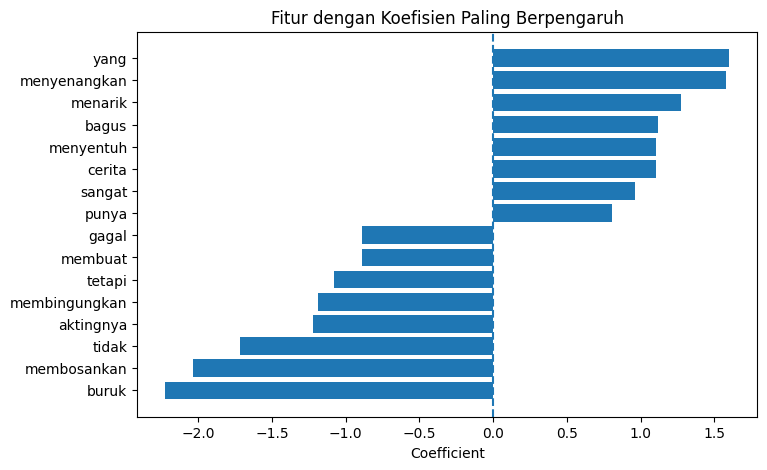

In [16]:
top_negative = coef_df.head(8)
top_positive = coef_df.tail(8)

plot_df = pd.concat([top_negative, top_positive])

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.xlabel("Coefficient")
plt.title("Fitur dengan Koefisien Paling Berpengaruh")
plt.axvline(0, linestyle="--")
plt.show()

## Advanced Tokenization, Stemming, dan Lemmatization

Tokenization adalah proses memecah teks menjadi unit kecil, biasanya kata. Pada vectorizer bawaan scikit-learn, tokenization dilakukan secara sederhana menggunakan pola tertentu.

Dalam pemrosesan teks yang lebih lanjut, terdapat teknik seperti:

- **Stemming**: memotong kata ke bentuk dasar secara heuristik.
- **Lemmatization**: mengubah kata ke bentuk dasar berdasarkan kamus dan konteks.
- **Spelling correction**: memperbaiki kesalahan penulisan.

Contoh:
- “running”, “runs”, “ran” dapat dinormalisasi menjadi “run”.
- “better” dapat dinormalisasi menjadi “good” pada lemmatization tertentu.

Teknik ini dapat membantu mengurangi jumlah variasi kata, tetapi juga dapat menambah kompleksitas preprocessing.

## Simulasi Normalisasi Kata Sederhana

Contoh berikut bukan stemming/lemmatization lengkap, tetapi menunjukkan ide bahwa beberapa variasi kata dapat dipetakan ke bentuk yang sama.

In [17]:
normalization_map = {
    "bagus": "bagus",
    "baik": "bagus",
    "menarik": "bagus",
    "buruk": "buruk",
    "jelek": "buruk",
    "membosankan": "buruk"
}

sample_words = ["bagus", "baik", "menarik", "buruk", "jelek", "membosankan"]

normalized = [normalization_map.get(word, word) for word in sample_words]

pd.DataFrame({
    "kata_asli": sample_words,
    "kata_normalisasi": normalized
})

,kata_asli,kata_normalisasi
0,bagus,bagus
1,baik,bagus
2,menarik,bagus
3,buruk,buruk
4,jelek,buruk
5,membosankan,buruk


## Topic Modeling dan Document Clustering

Selain klasifikasi supervised, data teks juga dapat dianalisis secara unsupervised. Dua contoh yang sering digunakan adalah:

- **Topic Modeling**: menemukan topik tersembunyi dalam kumpulan dokumen.
- **Document Clustering**: mengelompokkan dokumen berdasarkan kemiripan isi.

Walaupun chapter ini lebih banyak membahas representasi teks untuk klasifikasi, konsep vectorization seperti bag-of-words dan TF-IDF juga menjadi dasar untuk teknik unsupervised pada data teks.

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa data teks perlu diubah menjadi representasi numerik sebelum dapat digunakan oleh model machine learning. Representasi sederhana seperti bag-of-words bekerja dengan menghitung kemunculan kata, sedangkan TF-IDF memberi bobot berdasarkan tingkat kepentingan kata dalam dokumen dan corpus.

Poin penting dari chapter ini:

- Tidak semua string harus diperlakukan sebagai teks bebas.
- Bag-of-words mengubah dokumen menjadi vektor jumlah kata.
- Sparse matrix digunakan karena data teks biasanya memiliki banyak nilai nol.
- `CountVectorizer` digunakan untuk membuat representasi word count.
- `min_df` dan stopwords dapat mengurangi fitur yang kurang informatif.
- TF-IDF memberi bobot lebih tinggi pada kata yang lebih spesifik.
- n-grams membantu menangkap konteks sederhana seperti frasa dua atau tiga kata.
- Logistic Regression sering menjadi baseline yang kuat untuk klasifikasi teks.
- Pipeline membantu menggabungkan vectorizer dan model secara rapi.

Secara keseluruhan, chapter ini menunjukkan bahwa representasi teks merupakan langkah penting dalam text mining dan natural language processing berbasis machine learning.